# ___`MR-PMM` using `brms`___
---------------------

In [3]:
print(R.version$version.string)

[1] "R version 4.6.0 (2026-04-24 ucrt)"


In [ ]:
# https://cran.r-project.org/web/packages/brms/vignettes/brms_phylogenetics.html

# https://benjamin-halliwell.github.io/MR-PMM/MR-PMM_tutorial.html
# https://benjamin-halliwell.github.io/MR-PMM/MR-PMM_euc_example_analysis.html

# https://paulbuerkner.com/brms/articles/index.html
# https://paulbuerkner.com/brms/articles/brms_multivariate.html
# https://paulbuerkner.com/brms/articles/brms_phylogenetics.html
# https://paulbuerkner.com/brms/reference/brmsformula.html

# https://journal.r-project.org/articles/RJ-2018-017/index.html

In [5]:
suppressPackageStartupMessages({
    library("ape")
    library("brms")
    library("readxl")
    library("geiger")
})

In [7]:
packageVersion("geiger")

[1] '2.0.11'

In [6]:
packageVersion("brms")

[1] '2.23.0'

In [3]:
#------------------------------------------------------------------
# USING THE SUBSET WITH REPEATED RECORDS SINCE brms CAN HANDLE IT
#------------------------------------------------------------------

fred4 <- read.csv("../../data/chapter2/FRED/subsets/continuous_raw.csv")
# duplicating the binominal column with another name as brms won't allow the same variable to be duplicated as random effects (phylogenetic and non phylogenetic)
fred4$taxa <- fred4$binominal

# mycorrhizal state column
states <- readxl::read_xlsx(path = "../../data/chapter2/FRED/subsets/final.xlsx", sheet = "final")[, c("binominal", "state")] # dataset approved by Luke
states$binominal <- gsub(states$binominal, pattern = ' ', replacement = '_') # the binominal mnames column in this file has spaces instead of underscores

fred4 <- merge(x = fred4, y = states, by = "binominal", all.x = TRUE) # merge the mycorrhizal states column

# log and mean scale the continuous traits
fred4$F00679 <- scale(log(fred4$F00679))[, 1]
fred4$F00727 <- scale(log(fred4$F00727))[, 1]
fred4$F00709 <- scale(log(fred4$F00709))[, 1]

head(fred4)

,binominal,F01286,F01287,F01289,F00679,F00727,F00709,taxa,state
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,Abies_alba,Abies,alba,Pinaceae,0.1022601,0.01898775,-0.09495718,Abies_alba,EcM
2,Abies_alba,Abies,alba,Pinaceae,0.3021937,-0.50207617,0.44679293,Abies_alba,EcM
3,Abies_alba,Abies,alba,Pinaceae,0.5950494,0.99512162,-0.79519190,Abies_alba,EcM
4,Abies_nephrolepis,Abies,nephrolepis,Pinaceae,-0.2902498,0.21214483,0.14317141,Abies_nephrolepis,EcM
5,Acacia_auriculiformis,Acacia,auriculiformis,Fabaceae,-0.4679512,1.40509755,-0.03146336,Acacia_auriculiformis,EcMAM
6,Acacia_auriculiformis,Acacia,auriculiformis,Fabaceae,0.1630808,0.01069987,0.44679293,Acacia_auriculiformis,EcMAM


In [4]:
tree <- ape::read.tree("../../data/chapter2/uphylomaker/FRED4_1301.tre")
if(!ape::is.binary(tree)) tree <- ape::multi2di(tree)
stopifnot(all(tree$tip.label %in% fred4$binominal))

corrmat <- ape::vcv.phylo(phy = tree, corr = TRUE) # the issue with ape::vcv.phylo is that it uses a BM model to compute the variance covariance matrix - WE WANT TO USE AN OU PROCESS INSTEAD
# look up - https://discourse.mc-stan.org/t/rescaling-phylogenetic-tree-for-non-brownian-phylogenetic-models-in-brms/29637/4
# for this we can use rescale.phylo function from the R library geiger to transform a phylogeny into a OU phylogeny

In [31]:
ou_rescaler <- geiger:::rescale.phylo(tree, model = "OU") # to use functions that aren't exported by packages, use the triple colon syntax package:::function

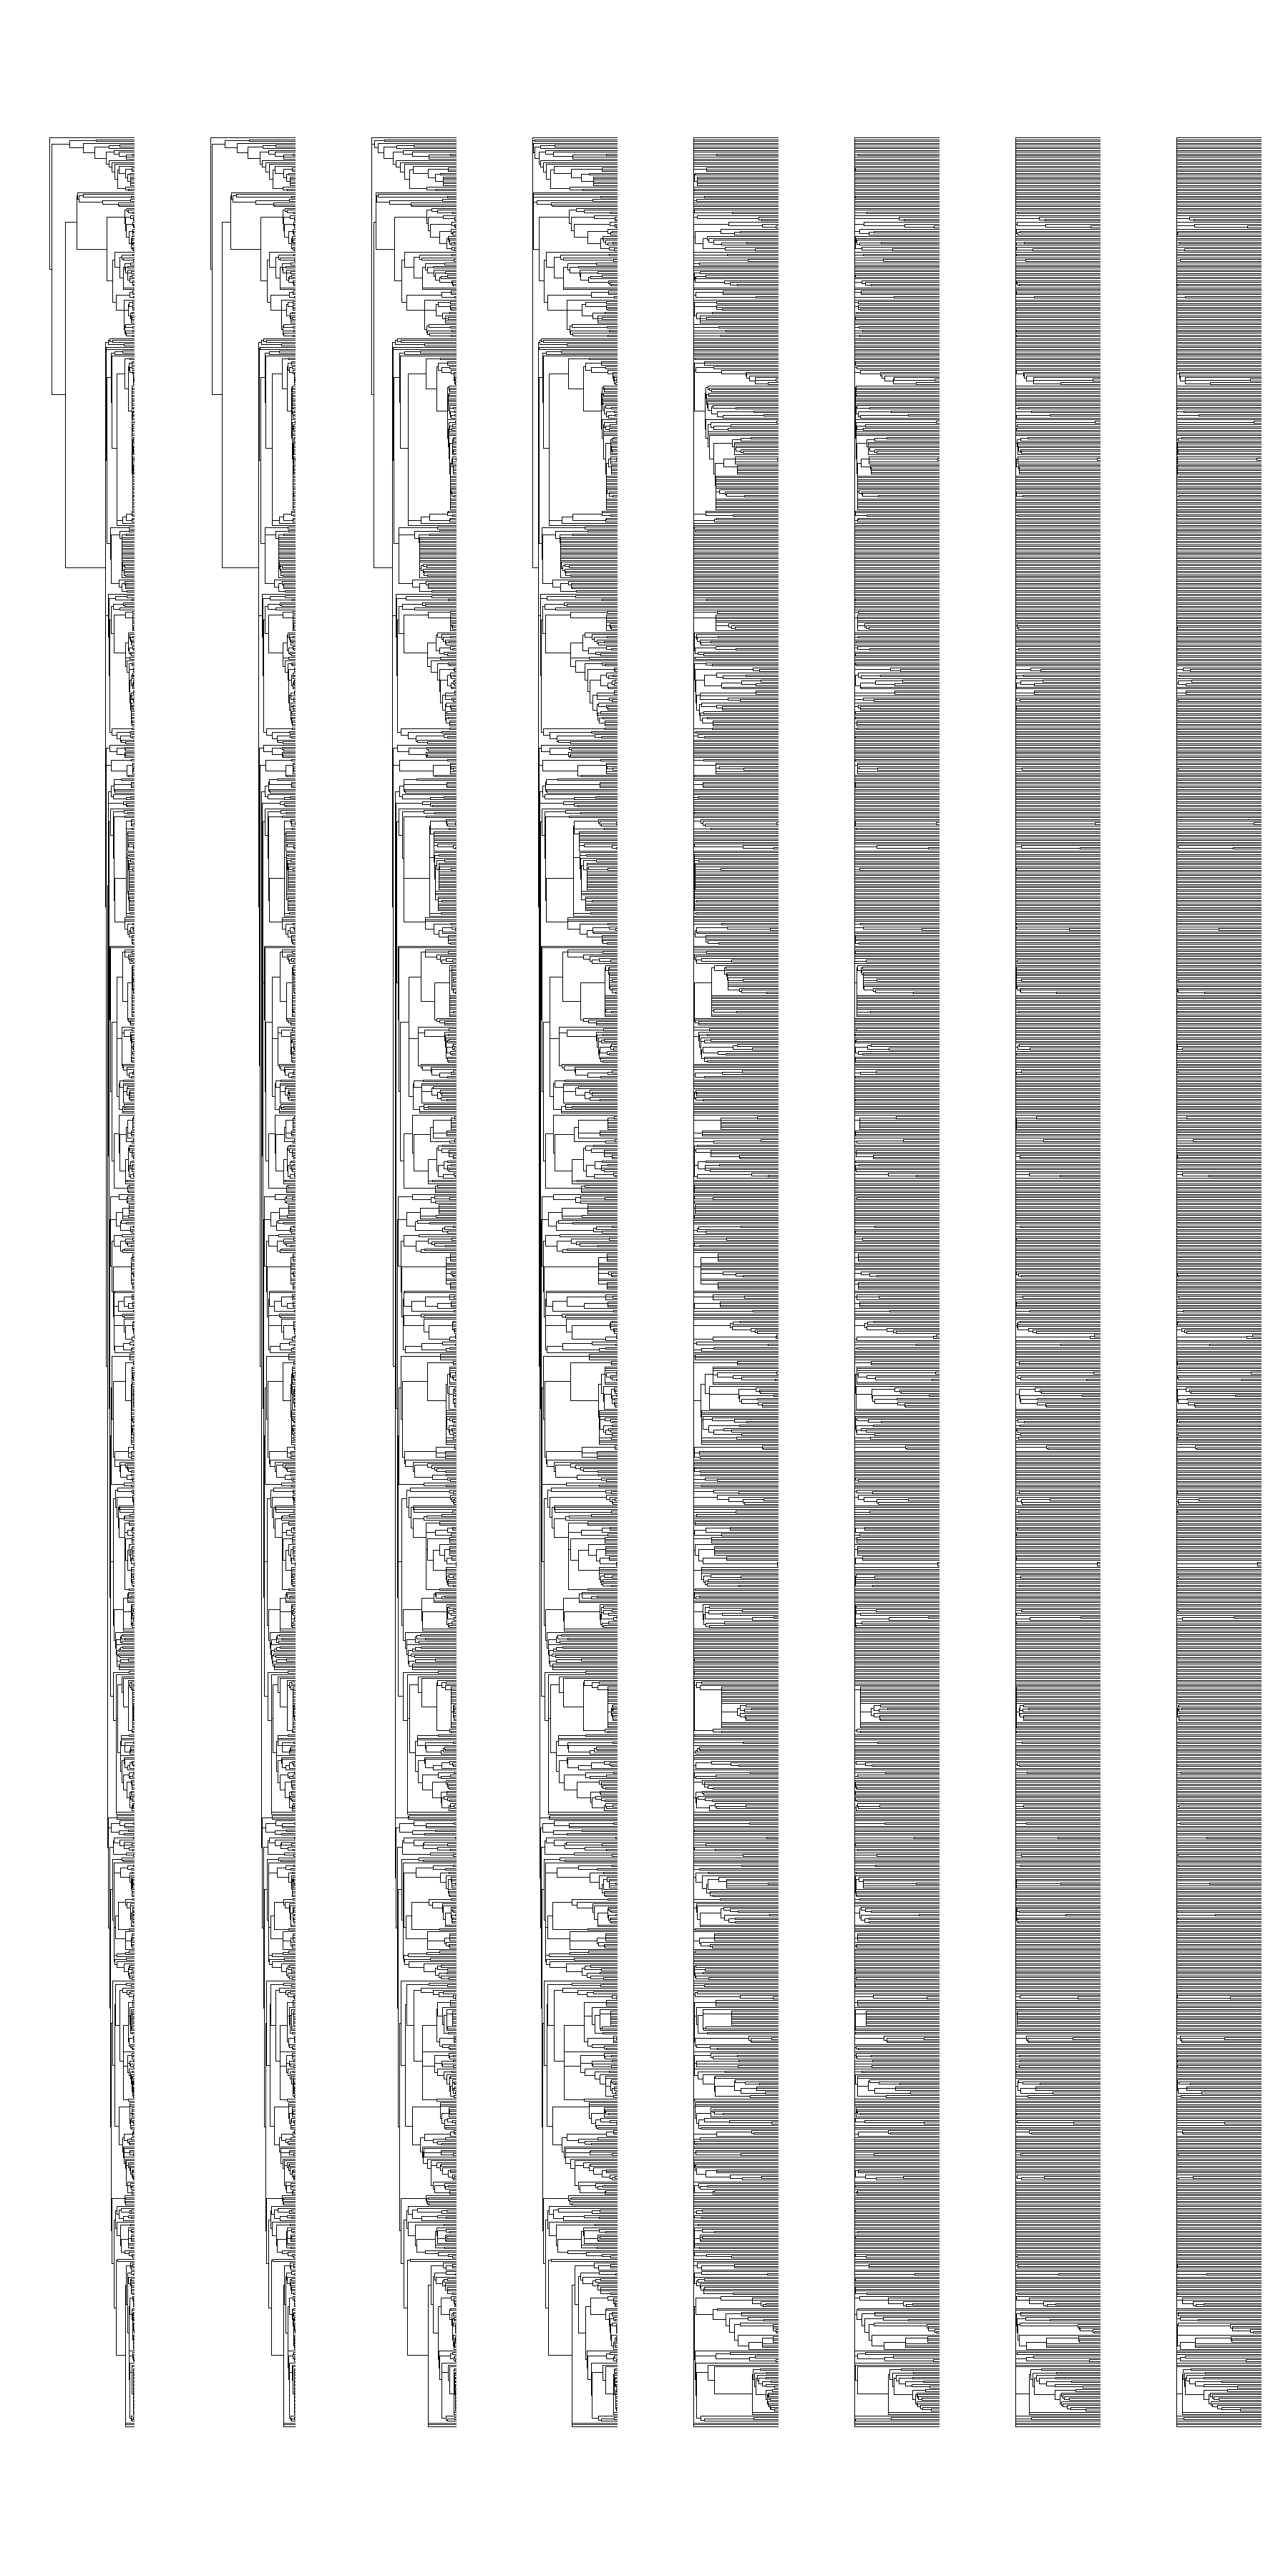

In [42]:
options(repr.plot.width = 15, repr.plot.height = 30)

par(mfrow = c(1, 8))

plot(tree, show.tip.label = FALSE)
plot(ou_rescaler(alpha = 0.001), show.tip.label = FALSE)
plot(ou_rescaler(alpha = 0.005), show.tip.label = FALSE)
plot(ou_rescaler(alpha = 0.01), show.tip.label = FALSE)
plot(ou_rescaler(alpha = 0.10), show.tip.label = FALSE)
plot(ou_rescaler(alpha = 0.25), show.tip.label = FALSE)
plot(ou_rescaler(alpha = 0.50), show.tip.label = FALSE)
plot(ou_rescaler(alpha = 0.75), show.tip.label = FALSE)

In [9]:
# mvbind() is used to bind multivariate response variables in brms

# https://paulbuerkner.com/brms/articles/brms_multivariate.html
# if we were to include a categorical trait that has repetitions and we want the model to factor in the within group correlations in that trait, we specify that trait the following way
# (1|p|trait) - here p is just an arbitrary choice - this template means - fit a random intercept over trait and consider within group correlations in that trait
# we can choose any alphabet or a number of our liking instead of p in the above formula
# HOWEVER, ONCE SPECIFIED, REUSE OF THAT SYMBOL AGAIN e.g. (1+x|i|g) and (1+z|i|g) WILL LEAD TO CORRELATIONS BEING COMPUTED BETWEEN THE TWO DIFFERENT INSTANCES OF THE GROUP EFFECT i

In [43]:
model_0 <- brms::brm(brms::brmsformula(mvbind(F00727, F00679, F00709) ~ state + (1|gr(binominal, cov = corrmat)) + (1|p|taxa)) + set_rescor(TRUE), # state is our predictor (fixed effect)
                   # (1|gr(binominal, cov = corrmat)) specifies that the relationships between the `binominal` are to be inferred from the covariance matrix `cov`
                   # our fourmula includes two random effects
                   # (1|gr(binominal, cov = corrmat)) will capture phylogenetic between species trait correlation while (1|taxa) will capture the non-phylogenetic between species trait correlation
                   # (1|taxa) is a basic multilevel model with a varying intercept over species (taxa)
                   # in (1|gr(binominal, cov = corrmat)), by using cov = corrmat in the gr function, we make sure that species are correlated as specified by the covariance matrix corrmat. 
                   data = fred4,
                   data2 = list(corrmat = corrmat), # data2 argument is to pass extra data that does not conform to the formulae's format
                   chains = 6, # each chain will be run in a separate process
                   cores = 6, # set this to the number of chains
                   threads = 4, # within chain (process) parallelization
                   iter = 10000)

# rescor - residual correlation - indicates if residual correlation between the response variables should be modeled.
# currently this is only possible in multivariate gaussian and student models and only relevant in multivariate models

saveRDS(object = model_0, file = "../../data/chapter2/rdata/brms_model_0.Rds")

Compiling Stan program...


Please download and install the appropriate version of Rtools for 4.6.0 from
https://cran.r-project.org/bin/windows/Rtools/.

Trying to compile a simple C file



Running "C:/R-4.6.0/bin/x64/Rcmd.exe" SHLIB foo.c
The system cannot find the path specified.
using C compiler: 'gcc.exe (GCC) 14.3.0'
gcc  -I"C:/R-4.6.0/include" -DNDEBUG     -I"C:/rtools45/x86_64-w64-mingw32.static.posix/include"      -O2 -Wall -std=gnu2x  -mfpmath=sse -msse2 -mstackrealign   -c foo.c -o foo.o
gcc -shared -s -static-libgcc -o foo.dll tmp.def foo.o -LC:/rtools45/x86_64-w64-mingw32.static.posix/lib/x64 -LC:/rtools45/x86_64-w64-mingw32.static.posix/lib -LC:/R-4.6.0/bin/x64 -lR



Please download and install the appropriate version of Rtools for 4.6.0 from
https://cran.r-project.org/bin/windows/Rtools/.

Warning message in system2(file.path(Sys.getenv("R_HOME"), "bin", "R"), args = "CMD SHLIB --dry-run", :
"running command '"C:/R-4.6.0/bin/R" CMD SHLIB --dry-run' had status 1"
Start sampling



In [ ]:
model_1 <- brms::brm(brms::brmsformula(mvbind(F00727, F00679, F00709) ~ state + (1|p|taxa)) + set_rescor(TRUE), # a model with no phylogegentic random effects
                        data = fred4, data2 = list(corrmat = corrmat), chains = 6, cores = 6, threads = 4, iter = 10000)

saveRDS(object = model_1, file = "../../data/chapter2/rdata/brms_model_1.Rds")

Compiling Stan program...


Please download and install the appropriate version of Rtools for 4.6.0 from
https://cran.r-project.org/bin/windows/Rtools/.

Trying to compile a simple C file



Running "C:/R-4.6.0/bin/x64/Rcmd.exe" SHLIB foo.c
The system cannot find the path specified.
using C compiler: 'gcc.exe (GCC) 14.3.0'
gcc  -I"C:/R-4.6.0/include" -DNDEBUG   -I"C:/R-4.6.0/library/Rcpp/include/"  -I"C:/R-4.6.0/library/RcppEigen/include/"  -I"C:/R-4.6.0/library/RcppEigen/include/unsupported"  -I"C:/R-4.6.0/library/BH/include" -I"C:/R-4.6.0/library/StanHeaders/include/src/"  -I"C:/R-4.6.0/library/StanHeaders/include/"  -I"C:/R-4.6.0/library/RcppParallel/include/" -DRCPP_PARALLEL_USE_TBB=1 -I"C:/R-4.6.0/library/rstan/include" -DEIGEN_NO_DEBUG  -DBOOST_DISABLE_ASSERTS  -DBOOST_PENDING_INTEGER_LOG2_HPP  -DSTAN_THREADS  -DUSE_STANC3 -DSTRICT_R_HEADERS  -DBOOST_PHOENIX_NO_VARIADIC_EXPRESSION  -D_HAS_AUTO_PTR_ETC=0  -include "C:/R-4.6.0/library/StanHeaders/include/stan/math/prim/fun/Eigen.hpp"  -std=c++1y    -I"C:/rtools45/x86_64-w64-mingw32.static.posix/include"      -O2 -Wall -std=gnu2x  -mfpmath=sse -msse2 -mstackrealign   -c foo.c -o foo.o
cc1.exe: warning: command-line opti


Please download and install the appropriate version of Rtools for 4.6.0 from
https://cran.r-project.org/bin/windows/Rtools/.

Warning message in system2(file.path(Sys.getenv("R_HOME"), "bin", "R"), args = "CMD SHLIB --dry-run", :
"running command '"C:/R-4.6.0/bin/R" CMD SHLIB --dry-run' had status 1"
Start sampling

